In [5]:
import os
import torch
import numpy as np

In [2]:
import torch.nn as nn

class AE_low(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.Conv1d(4, 6, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(6),
            nn.ReLU(),

            nn.Conv1d(6, 8, kernel_size=2, stride=2),
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.Conv1d(8, 10, kernel_size=6, stride=1),
            nn.BatchNorm1d(10), # tady mozna odstranit BN
            nn.Sigmoid(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(10, 8, kernel_size=6, stride=1),
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.ConvTranspose1d(8, 6, kernel_size=2, stride=2),
            nn.BatchNorm1d(6),
            nn.ReLU(),

            nn.ConvTranspose1d(6, 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.ConvTranspose1d(4, 1, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [4]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "SVDD_v1.pth"), map_location="cpu")

config = checkpoint["config"]

model = AE_low()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

AE_low(
  (encoder): Sequential(
    (0): Conv1d(1, 4, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(4, 6, kernel_size=(4,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(6, 8, kernel_size=(2,), stride=(2,))
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv1d(8, 10, kernel_size=(6,), stride=(1,))
    (10): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Sigmoid()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(10, 8, kernel_size=(6,), stride=(1,))
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose1d(8, 6, kernel_size=(2,), stride=(2,))
    (4): BatchNorm1d(6, eps=1e-05, momentum=0.

In [6]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [16]:
pt = torch.tensor(full_dataset[0]).reshape(1,1,96)
model.eval()
x = model.encoder(pt)
print(x.shape)
print(torch.flatten(x).shape)

torch.Size([1, 10, 7])
torch.Size([70])


In [39]:
model.eval()
embeddings = []

with torch.no_grad():  
    for data in X_train:
        data_tensor = torch.as_tensor(data, dtype=torch.float32).reshape(1, 1, 96)
        
        embed = model.encoder(data_tensor)
        
        embeddings.append(embed.flatten())

embeddings_stack = torch.stack(embeddings)
center = torch.mean(embeddings_stack, dim=0)

In [45]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset
from anomaly_detection.utils.losses import HyperSphereLoss

batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = HyperSphereLoss(center=center)
lam = 10e-4

n_epochs = 100
optimizer = torch.optim.Adam(params=model.encoder.parameters(), lr=0.0001)

In [ ]:
model.train()

losses = []

for ep in range(n_epochs):
    for x in train_loader:
        embed = model.encoder(x)
        embed = embed.view(x.size(0), -1)
        
        loss = criterion(embed)
        losses.append(loss.detach().numpy())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if ep % 20 == 0:
        print(f"Ep: {ep} loss: {loss}")
        

Ep: 0 loss: 1.138529896736145
Ep: 20 loss: 0.9870093464851379
Ep: 40 loss: 1.262110948562622
Ep: 60 loss: 0.9753593802452087
Ep: 80 loss: 0.813414990901947


In [53]:
full_dataset = HistDataset(full_dataset)

In [83]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))
eval_df = HistDataset(eval_df['histogram'].values)

In [77]:
def score_svdd(df, encoder):
    scores = []
    with torch.no_grad():
        for pt in df:
            if not type(pt) == torch.Tensor:
                pt = torch.tensor(pt)
            pt = torch.flatten(encoder(pt.reshape(1,1,96)).detach())
            scores.append(torch.sum((pt-center)**2))
    return scores

In [ ]:
scores = []
with torch.no_grad():
    for pt in full_dataset:
        if not type(pt) == torch.Tensor:
            pt = torch.tensor(pt) 
        pt = torch.flatten(model.encoder(pt.reshape(1,1,96)).detach())
        scores.append(torch.sum((pt-center)**2))

In [72]:
scores = score_svdd(full_dataset, model.encoder)

In [86]:
eval_score = score_svdd(eval_df, model.encoder)

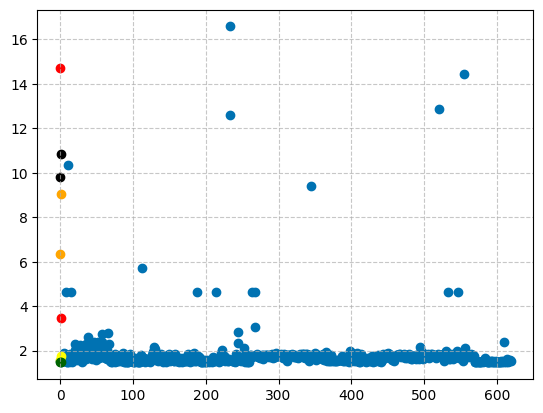

In [89]:
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')

In [59]:
scores = score_svdd(full_dataset, model.encoder)

RuntimeError: running_mean should contain 48 elements not 4

In [70]:
outliers = np.where(np.array(scores) > 4)
outliers

(array([  8,  11,  15, 112, 188, 214, 233, 234, 263, 268, 344, 520, 533,
        546, 555]),)